### Exploratory Data Analysis (EDA) & Data Overview

In [ ]:
# -----------------------------
# Imports + Reproducibility
# -----------------------------
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, roc_auc_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [ ]:
# Load Data
df = pd.read_csv('diabetic_data.csv')

# Handle actual missing values (encoded as '?' in this dataset)
df.replace('?', np.nan, inplace=True)

# FIX: Prevent "None" (valid clinical category) from being treated as missing
df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
df['A1Cresult'] = df['A1Cresult'].fillna('None')

# Calculate TRUE Missing Values Percentage
missing_pct = df.isnull().sum() / len(df) * 100

print("--- TRUE Missing Values Percentage ---")
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

--- TRUE Missing Values Percentage ---
weight                      96.685524
payer_code                  48.401397
medical_specialty           43.300816
race                         2.020645
diag_3                       1.667547
diag_2                       0.417531
diag_1                       0.024485
discharge_disposition_id     0.001289
time_in_hospital             0.001289
admission_source_id          0.001289
num_lab_procedures           0.001289
admission_type_id            0.001289
gender                       0.001289
age                          0.001289
number_outpatient            0.001289
num_medications              0.001289
num_procedures               0.001289
number_inpatient             0.001289
number_emergency             0.001289
number_diagnoses             0.001289
metformin                    0.001289
repaglinide                  0.001289
nateglinide                  0.001289
chlorpropamide               0.001289
glimepiride                  0.001289
acetohexami

1. Dataset Shape: 101,766 x 50.
2. Missing Values:
- weight: ~97% missing (significant data loss) --> systematically missing? why?
- medical_specialty: ~49% missing.
- payer_code: ~40% missing.
- --> drop? or keep for further analysis?
4. Data Types: A mix of numerical (int) and categorical (object) features. IDs like admission_type_id are technically numeric but represent categories.  

#### Working with numerical features

--- Statistical Summary ---
                      count       mean        std  min   25%   50%   75%  \
time_in_hospital    77598.0   4.475154   3.027743  1.0   2.0   4.0   6.0   
num_lab_procedures  77598.0  43.171319  19.157213  1.0  32.0  44.0  56.0   
num_procedures      77598.0   1.337560   1.681772  0.0   0.0   1.0   2.0   
num_medications     77598.0  15.761218   8.142731  1.0  10.0  14.0  20.0   
number_diagnoses    77598.0   7.214387   1.976757  1.0   6.0   8.0   9.0   
number_outpatient   77598.0   0.325111   1.176248  0.0   0.0   0.0   0.0   
number_emergency    77598.0   0.168973   0.752060  0.0   0.0   0.0   0.0   
number_inpatient    77598.0   0.625119   1.240019  0.0   0.0   0.0   1.0   

                      max  
time_in_hospital     14.0  
num_lab_procedures  129.0  
num_procedures        6.0  
num_medications      81.0  
number_diagnoses      9.0  
number_outpatient    42.0  
number_emergency     46.0  
number_inpatient     21.0  

--- Skewness ---
time_in_hospital 

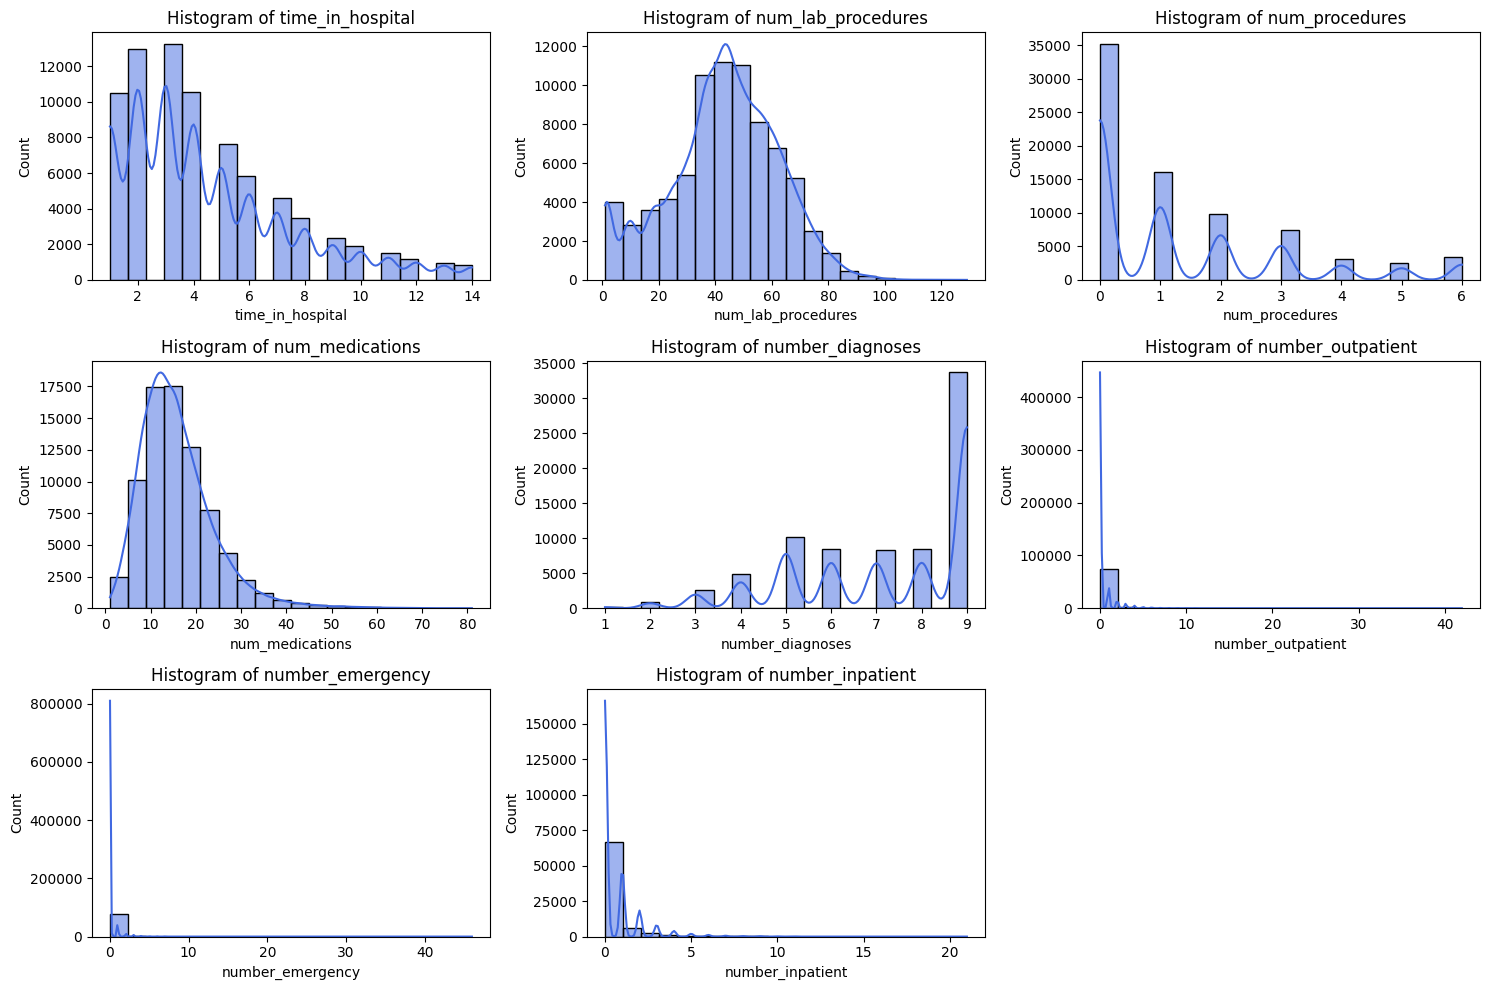

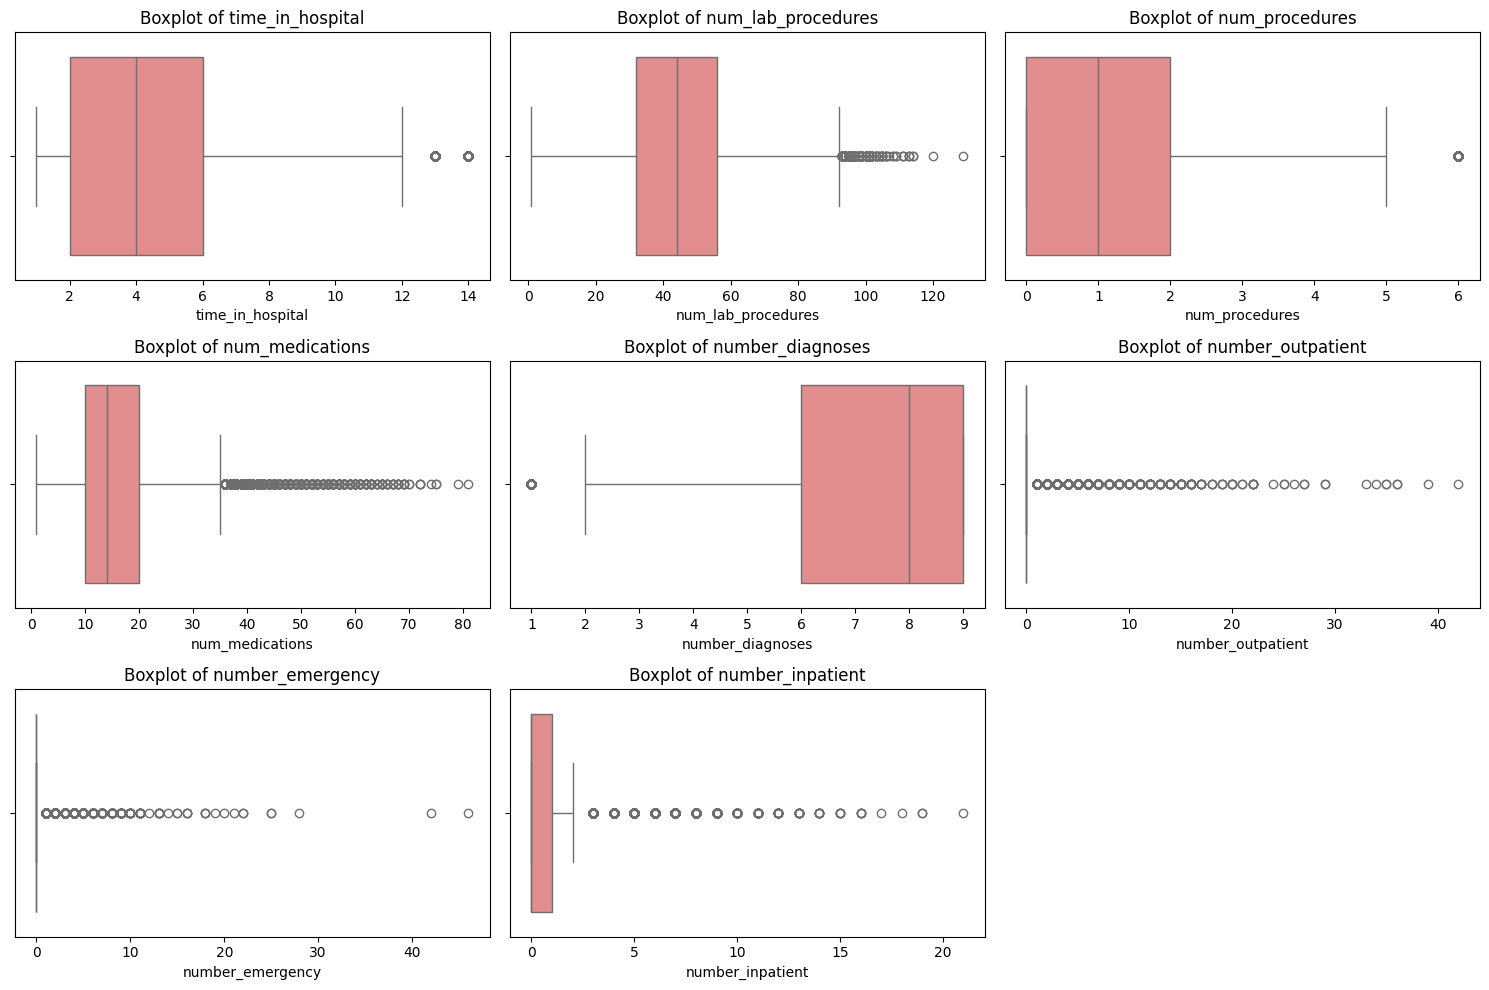

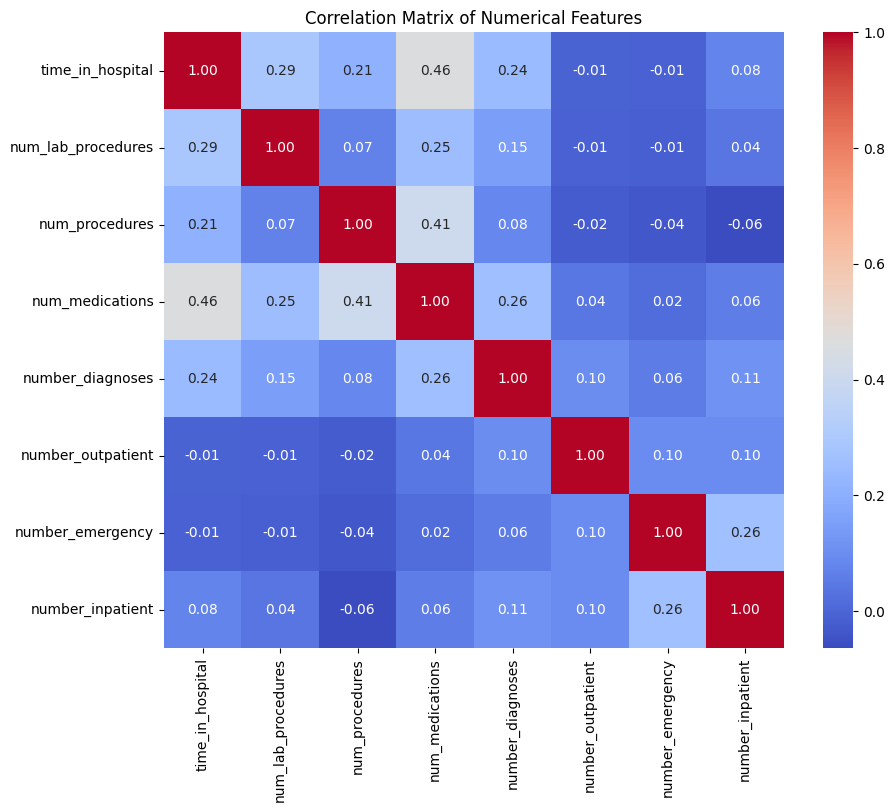

In [ ]:
#  Define Numerical Features
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_diagnoses', 'number_outpatient',
            'number_emergency', 'number_inpatient']

#  Statistical Summary and Skewness
print("--- Statistical Summary ---")
print(df[num_cols].describe().T)

print("\n--- Skewness ---")
print(df[num_cols].skew())

#  Histograms for Skewness
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True, bins=20, color='royalblue')
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

#  Boxplots for Outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Correlation Matrix of continuous variables
num_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_diagnoses', 'number_outpatient',
            'number_emergency', 'number_inpatient']
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

4. Skewness: Most numerical features are highly right-skewed, meaning most patients have 0 prior visits/emergencies, but a few have many
5. outliers: Right-skewed distributions across the board. Every single variable shows outliers exclusively above the upper whisker. These likely represent chronic disease patients, complex surgical cases, or patients with complications - the cohort that drives healthcare costs and requires specialized care protocols.
6. correlation: time_in_hospital has a moderate positive correlation with num_medications (0.47) and num_lab_procedures (0.32) --> The longer patients stay, the more procedures --> reasonable
7. LOS (Target): The Length of Stay (LOS) is right-skewed (skewness = 1.12), with the majority of patients staying between 2 to 4 days.

#### Working with categorical features

/tmp/ipykernel_1980/4039085790.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='race', data=df, order=df['race'].value_counts().index, palette='Set2')
/tmp/ipykernel_1980/4039085790.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='Set1')


TypeError: '<' not supported between instances of 'float' and 'str'

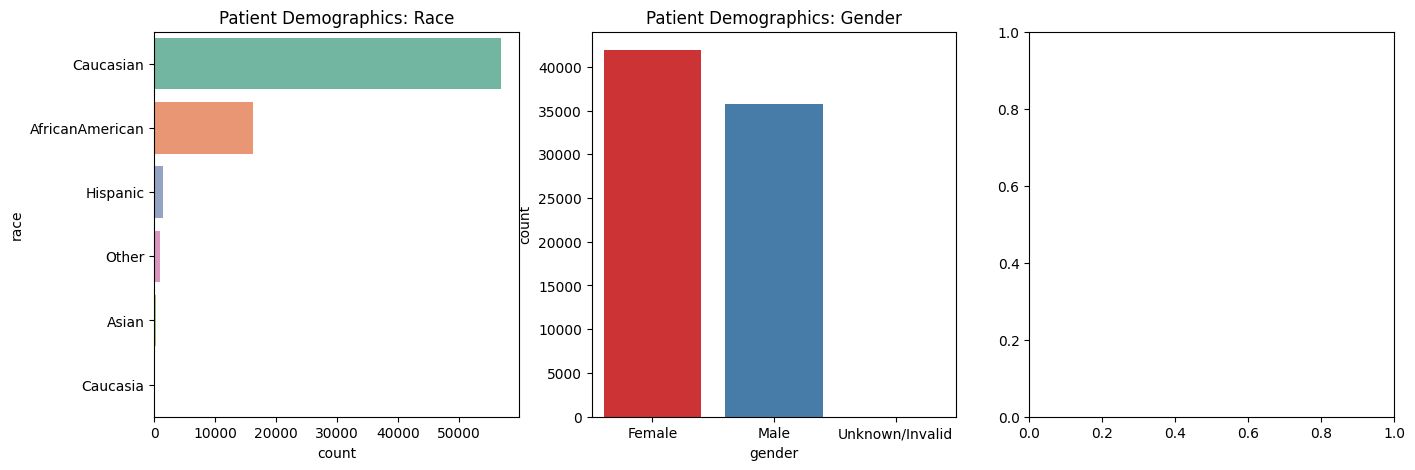

In [ ]:
plt.figure(figsize=(16, 5))

# Race
plt.subplot(1, 3, 1)
sns.countplot(y='race', data=df, order=df['race'].value_counts().index, palette='Set2')
plt.title('Patient Demographics: Race')

# Gender
plt.subplot(1, 3, 2)
sns.countplot(x='gender', data=df, palette='Set1')
plt.title('Patient Demographics: Gender')

# Age
plt.subplot(1, 3, 3)
sns.countplot(x='age', data=df, order=sorted(df['age'].unique()), palette='viridis')
plt.title('Patient Demographics: Age Group')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1980/2546550842.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='race', data=df, order=df['race'].value_counts().index, palette='Set2')
/tmp/ipykernel_1980/2546550842.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=df, palette='Set1')
/tmp/ipykernel_1980/2546550842.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age', data=df, order=sorted(df['age'].dropna().unique()), palette='viridis')


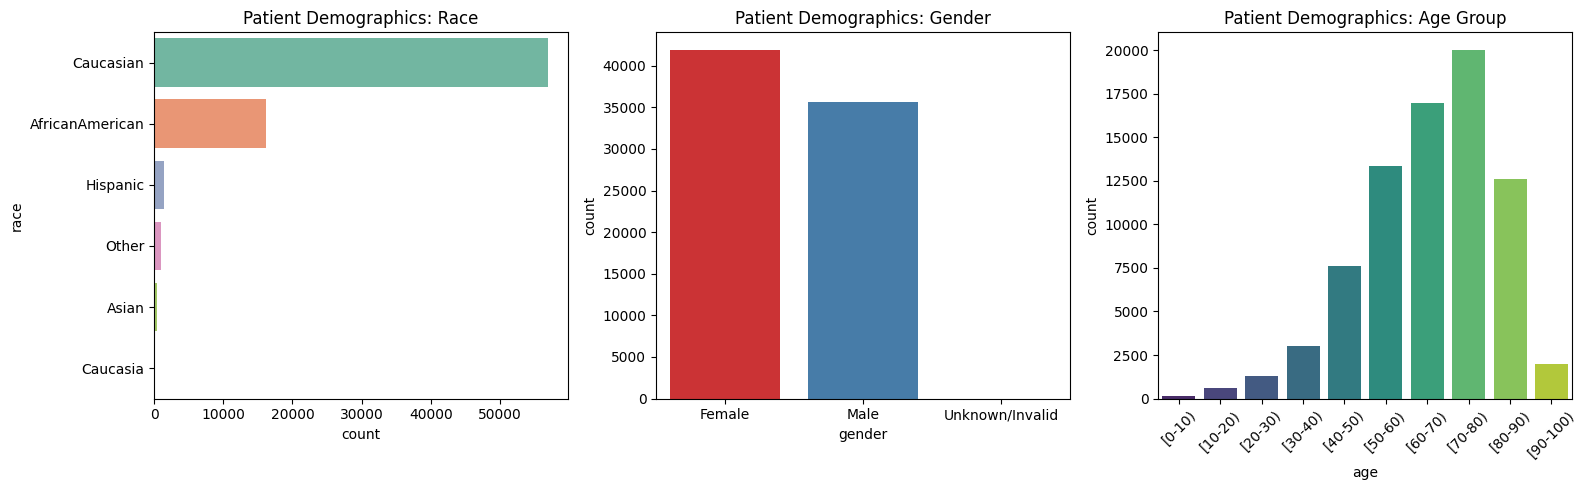

In [ ]:
plt.figure(figsize=(16, 5))

# Race
plt.subplot(1, 3, 1)
sns.countplot(y='race', data=df, order=df['race'].value_counts().index, palette='Set2')
plt.title('Patient Demographics: Race')

# Gender
plt.subplot(1, 3, 2)
sns.countplot(x='gender', data=df, palette='Set1')
plt.title('Patient Demographics: Gender')

# Age
plt.subplot(1, 3, 3)
sns.countplot(x='age', data=df, order=sorted(df['age'].dropna().unique()), palette='viridis')
plt.title('Patient Demographics: Age Group')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

- Most diabetic patients are Caucasian.
- Female patients tend to have a higher probability of having diabetes.
- Patients aged 50 to 90 have a higher incidence of diabetes compared to younger generations.

#### Weight Missingness Pattern Analysis

Overall Weight Missing Rate: 96.69%



/tmp/ipykernel_1980/2110762526.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='admission_type_id', y='mean', data=adm_missing, palette='Blues_r')
/tmp/ipykernel_1980/2110762526.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='med_spec_clean', x='mean', data=top_units, palette='magma')
/tmp/ipykernel_1980/2110762526.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_missing = df_sorted.groupby('time_period')['weight_missing'].agg(['mean', 'count']).reset_index()


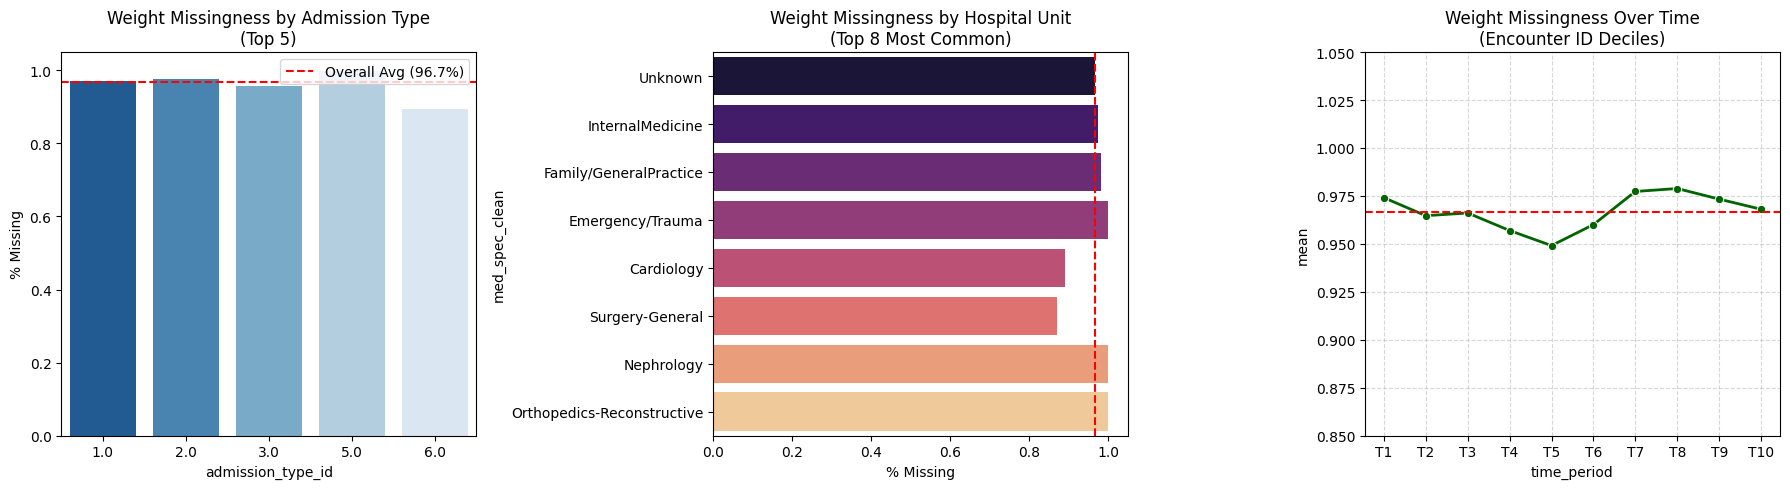

In [ ]:
# Create missing flag BEFORE converting ? to NaN (or use isna() after)
# Since we already replaced ? with NaN in Cell 1, we use:
df['weight_missing'] = df['weight'].isna().astype(int)

overall_missing_rate = df['weight_missing'].mean()
print(f"Overall Weight Missing Rate: {overall_missing_rate:.2%}\n")

plt.figure(figsize=(18, 5))

# 1. By Admission Type (Top 5)
adm_missing = df.groupby('admission_type_id')['weight_missing'].agg(['mean', 'count']).reset_index()
adm_missing = adm_missing.sort_values('count', ascending=False).head(5)

plt.subplot(1, 3, 1)
sns.barplot(x='admission_type_id', y='mean', data=adm_missing, palette='Blues_r')
plt.axhline(overall_missing_rate, color='red', linestyle='--', label=f'Overall Avg ({overall_missing_rate:.1%})')
plt.title('Weight Missingness by Admission Type\n(Top 5)', fontsize=12)
plt.ylabel('% Missing')
plt.ylim(0, 1.05)
plt.legend()

# 2. By Hospital Unit (Medical Specialty)
df['med_spec_clean'] = df['medical_specialty'].fillna('Unknown')
unit_missing = df.groupby('med_spec_clean')['weight_missing'].agg(['mean', 'count']).reset_index()
top_units = unit_missing.sort_values('count', ascending=False).head(8)

plt.subplot(1, 3, 2)
sns.barplot(y='med_spec_clean', x='mean', data=top_units, palette='magma')
plt.axvline(overall_missing_rate, color='red', linestyle='--')
plt.title('Weight Missingness by Hospital Unit\n(Top 8 Most Common)', fontsize=12)
plt.xlabel('% Missing')
plt.xlim(0, 1.05)

# 3. Over Time (using encounter_id as time proxy)
df_sorted = df.sort_values('encounter_id').copy()
df_sorted['time_period'] = pd.qcut(df_sorted['encounter_id'], q=10, labels=[f"T{i}" for i in range(1, 11)])

time_missing = df_sorted.groupby('time_period')['weight_missing'].agg(['mean', 'count']).reset_index()

plt.subplot(1, 3, 3)
sns.lineplot(x='time_period', y='mean', data=time_missing, marker='o', color='darkgreen', linewidth=2)
plt.axhline(overall_missing_rate, color='red', linestyle='--')
plt.title('Weight Missingness Over Time\n(Encounter ID Deciles)', fontsize=12)
plt.ylim(0.85, 1.05)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


This is a systematic data collection failure, not a clinical pattern. The hospital's Electronic Health Record (EHR) system likely did not mandate the weight field, or the database query used to extract this dataset failed to pull the vitals correctly.
--> We can drop the "weight" column without fear of introducing clinical bias.

### Feature Engineering & Data Preparation

#### Handling missing value & Feature Engineering

/tmp/ipykernel_1980/4155380498.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='payer_category', y='time_in_hospital', data=df, order=order_payer, palette='viridis')
/tmp/ipykernel_1980/4155380498.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='has_specialty', y='time_in_hospital', data=df, palette='Set1', errorbar=None)
/tmp/ipykernel_1980/4155380498.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diag_count', y='is_long_stay', data=df, palette='coolwarm', errorbar=None)


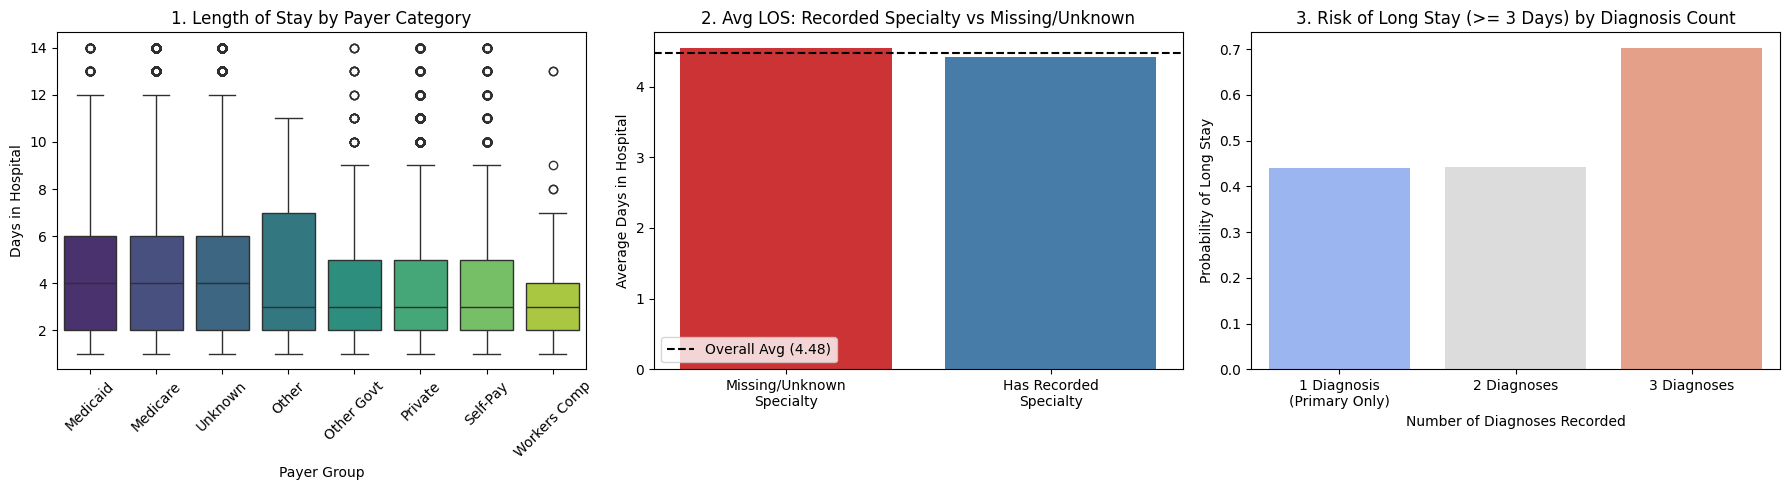

Data shape: (77599, 56)


In [ ]:
# A. Diagnosis Missingness
df['diag_1'] = df['diag_1'].fillna('Unknown Primary')
df['diag_2'] = df['diag_2'].fillna('No Secondary Diagnosis')
df['diag_3'] = df['diag_3'].fillna('No Tertiary Diagnosis')

# Feature Engineer: Count of Diagnoses
df['diag_count'] = 3
df.loc[df['diag_3'] == 'No Tertiary Diagnosis', 'diag_count'] = 2
df.loc[(df['diag_2'] == 'No Secondary Diagnosis') & (df['diag_3'] == 'No Tertiary Diagnosis'), 'diag_count'] = 1

# B. Medical Specialty Missingness
    # This checks for NaN, '?', OR our custom 'Unknown' string so it never breaks on a re-run
df['has_specialty'] = np.where(df['medical_specialty'].isin([np.nan, '?', 'Unknown/Not Specified']), 0, 1)
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown/Not Specified')

# C. Payer Code Mapping
payer_mapping = {
    'MC': 'Medicare', 'MP': 'Medicare',
    'MD': 'Medicaid', 'SP': 'Self-Pay',
    'HM': 'Private', 'CP': 'Private', 'CM': 'Private',
    'PO': 'Private', 'CH': 'Private', 'SI': 'Private',
    'BC': 'Private', 'DM': 'Private',
    'OG': 'Other Govt', 'FR': 'Other Govt',
    'WC': 'Workers Comp', 'OT': 'Other', 'UN': 'Unknown'
}
df['payer_category'] = df['payer_code'].map(payer_mapping).fillna('Unknown')

# Define binary target for Plot 3
df['is_long_stay'] = (df['time_in_hospital'] >= 3).astype(int)

# ==========================================
# CREATE THE PLOTS
# ==========================================
plt.figure(figsize=(18, 5))

# --- Plot 1: Length of Stay by Payer Category (Boxplot) ---
plt.subplot(1, 3, 1)
order_payer = df.groupby('payer_category')['time_in_hospital'].median().sort_values(ascending=False).index
sns.boxplot(x='payer_category', y='time_in_hospital', data=df, order=order_payer, palette='viridis')
plt.title('1. Length of Stay by Payer Category', fontsize=12)
plt.ylabel('Days in Hospital')
plt.xlabel('Payer Group')
plt.xticks(rotation=45)

# --- Plot 2: Missing Specialty vs Length of Stay ---
plt.subplot(1, 3, 2)
sns.barplot(x='has_specialty', y='time_in_hospital', data=df, palette='Set1', errorbar=None)
plt.title('2. Avg LOS: Recorded Specialty vs Missing/Unknown', fontsize=12)
plt.xticks([0, 1], ['Missing/Unknown\nSpecialty', 'Has Recorded\nSpecialty'])
plt.ylabel('Average Days in Hospital')
plt.xlabel('')
plt.axhline(df['time_in_hospital'].mean(), color='black', linestyle='--', label=f'Overall Avg ({df["time_in_hospital"].mean():.2f})')
plt.legend()

# --- Plot 3: Impact of Diagnosis Count on Long Stay Risk ---
plt.subplot(1, 3, 3)
sns.barplot(x='diag_count', y='is_long_stay', data=df, palette='coolwarm', errorbar=None)
plt.title('3. Risk of Long Stay (>= 3 Days) by Diagnosis Count', fontsize=12)
plt.xlabel('Number of Diagnoses Recorded')
plt.ylabel('Probability of Long Stay')
plt.xticks([0, 1, 2], ['1 Diagnosis\n(Primary Only)', '2 Diagnoses', '3 Diagnoses'])

plt.tight_layout()
plt.show()

print(f"Data shape: {df.shape}")

I don't want to drop those records with missing values, as I want to know the statistical power for high-utilization outlier detection. So, I keep all records and handle missing values using encoding strategies rather than deletion.
- For diag_1 (primary diagnosis):
    - 0.02% missing is negligible - just code these as "unknown primary"

- For diag_2, diag_3 (secondary diagnoses):
    - Missing = no secondary/tertiary diagnosis (this is clinical reality!)
      Many patients only have a primary diagnosis - this is valid data, not missing data

- For race:
    - Create "Unknown/Not Reported" category
    - I did not drop missing values. Race patterns in diabetes care are important for equity analysis

- For medical_specialty (49% missing) - I did not use mode this time
    Instead, I Create binary flags: "has_specialty" vs "missing_specialty"

- For payer_code (40% missing) - Pattern is information
    I group them into: Medicare (Federal health insurance), Medicaid (State-federal health program), Private, Self-pay, Unknown

In [ ]:
# Drop Weight coulmn
df.drop(columns=('weight'), inplace=True)

# Simplify Age to numerical midpoints (Ordinal Mapping)
age_mapping = {'[0-10)': 5, '[10-20)': 15, '[20-30)': 25, '[30-40)': 35, '[40-50)': 45,
               '[50-60)': 55, '[60-70)': 65, '[70-80)': 75, '[80-90)': 85, '[90-100)': 95}
df['age_num'] = df['age'].map(age_mapping)

print(f"Remaining dataset shape after cleaning: {df.shape}")

Remaining dataset shape after cleaning: (77599, 56)


### Clustering Patients using PCA

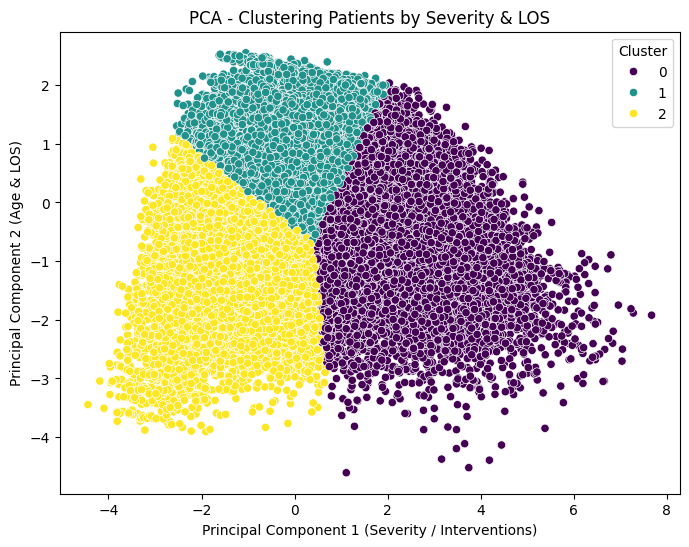

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Select severity features
features = ['age_num', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'time_in_hospital']
pca_data = df[features].dropna()

# Standardize data
scaler = StandardScaler()
pca_data_scaled = scaler.fit_transform(pca_data)

# Apply PCA
pca = PCA(n_components=2)
pca_df = pd.DataFrame(data=pca.fit_transform(pca_data_scaled), columns=['PC1', 'PC2'])

# Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
pca_df['Cluster'] = kmeans.fit_predict(pca_df[['PC1', 'PC2']])

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis')
plt.title('PCA - Clustering Patients by Severity & LOS')
plt.xlabel('Principal Component 1 (Severity / Interventions)')
plt.ylabel('Principal Component 2 (Age & LOS)')
plt.show()

Goal: Identify high-risk patient groups based on severity, age, and comorbidities.
--> Using PCA to reduce dimensions, K-Means successfully identified 3 distinct patient clusters. One cluster represents straightforward short-stays, while the other two capture varying degrees of complexity (e.g., elderly patients with high diagnosis counts).

### Data Partitioning & Baseline Modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, PoissonRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Select features
X = df[['age_num', 'num_lab_procedures', 'num_procedures', 'num_medications',
        'number_diagnoses', 'number_outpatient', 'number_emergency', 'number_inpatient']]
X = X.fillna(X.median()) # This handles NaNs in X features

y = df['time_in_hospital']

# Combine X and y, then drop rows where y is NaN to ensure alignment
combined_df = pd.concat([X, y], axis=1).dropna(subset=['time_in_hospital'])
X = combined_df.drop(columns=['time_in_hospital'])
y = combined_df['time_in_hospital']

# Log transform target to handle skewness
y_log = np.log1p(y)

# Partition Data: 70% Train, 15% Valid, 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(X, y_log, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Evaluation Helper
def evaluate(y_true_log, y_pred_log, model_name):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f"--- {model_name} ---")
    print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | MAPE: {mape:.4f}\n")
    return rmse

# 1. Linear Regression Baseline
lr = LinearRegression().fit(X_train, y_train)
baseline_rmse = evaluate(y_test, lr.predict(X_test), "Linear Regression")

# 2. Poisson Regression Baseline (Trained on actual counts)
pr = PoissonRegressor(alpha=1e-4).fit(X_train, np.expm1(y_train))
pr_preds = pr.predict(X_test)
pr_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), pr_preds))
print(f"--- Poisson Regression ---")
print(f"RMSE: {pr_rmse:.4f} | MAE: {mean_absolute_error(np.expm1(y_test), pr_preds):.4f}\n")

--- Linear Regression ---
RMSE: 2.6964 | MAE: 1.9548 | MAPE: 0.5957

--- Poisson Regression ---
RMSE: 2.6455 | MAE: 2.0117



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_glm/glm.py:285: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)


### Advanced Modeling

--- HistGradientBoostingRegressor ---
RMSE: 2.5740 | MAE: 1.8707 | MAPE: 0.5668

🎯 RMSE Reduction vs Baseline (LR): 4.54%


/tmp/ipykernel_1980/4234450752.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='magma')


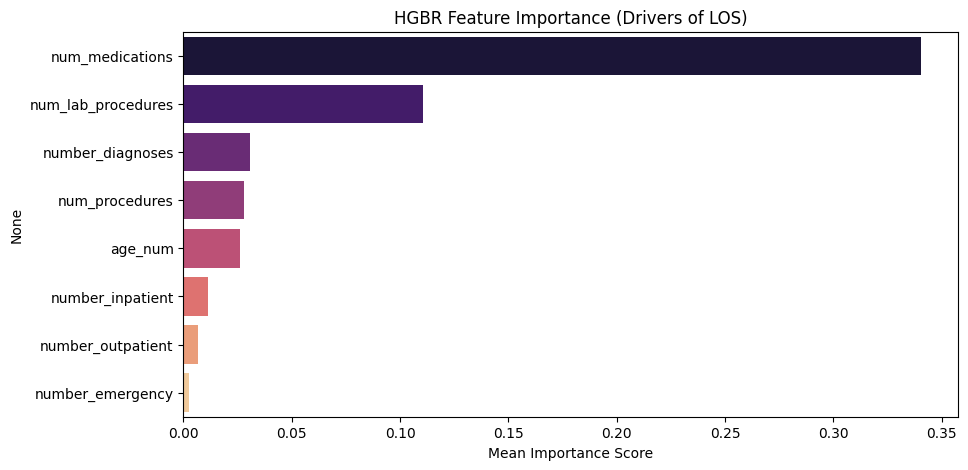

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

# Train Tree-based Model (Equivalent to LightGBM/XGBoost)
hgbr = HistGradientBoostingRegressor(max_iter=100, max_depth=5, learning_rate=0.1, random_state=42)
hgbr.fit(X_train, y_train)

# Predict and Evaluate
hgbr_rmse = evaluate(y_test, hgbr.predict(X_test), "HistGradientBoostingRegressor")
print(f"🎯 RMSE Reduction vs Baseline (LR): {((baseline_rmse - hgbr_rmse) / baseline_rmse) * 100:.2f}%")

# Feature Importance using Permutation Importance
result = permutation_importance(hgbr, X_test, y_test, n_repeats=5, random_state=42)
feat_imp = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='magma')
plt.title("HGBR Feature Importance (Drivers of LOS)")
plt.xlabel("Mean Importance Score")
plt.show()

### Bed Allocation Queue Simulation & What-If Scenario

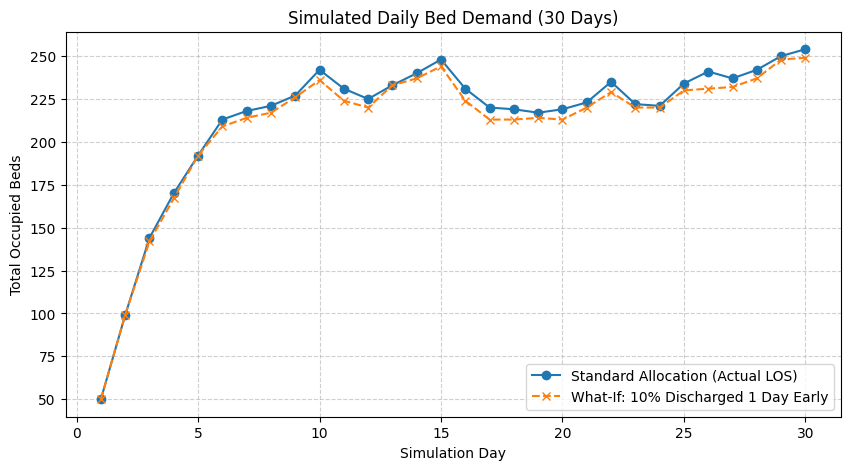

In [ ]:
# Create DataFrame comparing Actual vs Predicted
preds = np.expm1(hgbr.predict(X_test))
test_results = pd.DataFrame({'Actual_LOS': np.expm1(y_test), 'Predicted_LOS': preds})

# Round to nearest whole days for physical bed occupancy
test_results['Actual_LOS_Rounded'] = np.ceil(test_results['Actual_LOS']).astype(int)

# Simulation Parameters
days = 30
daily_arrivals = 50
bed_demand = np.zeros(days)
what_if_demand = np.zeros(days)

np.random.seed(42) # For reproducibility

for day in range(days):
    # Simulate 50 new patients arriving today
    arrivals = test_results.sample(daily_arrivals, replace=True)

    for _, row in arrivals.iterrows():
        los = int(row['Actual_LOS_Rounded'])

        # Standard tracking: Patient occupies a bed for 'los' days
        for i in range(day, min(day + los, days)):
            bed_demand[i] += 1

        # What-If tracking: 10% chance of discharging 1 day early (if stay > 1 day)
        if np.random.rand() < 0.1 and los > 1:
            los_whatif = los - 1
        else:
            los_whatif = los

        for i in range(day, min(day + los_whatif, days)):
            what_if_demand[i] += 1

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(range(1, days+1), bed_demand, marker='o', label='Standard Allocation (Actual LOS)')
plt.plot(range(1, days+1), what_if_demand, marker='x', linestyle='--', label='What-If: 10% Discharged 1 Day Early')
plt.title('Simulated Daily Bed Demand (30 Days)')
plt.xlabel('Simulation Day')
plt.ylabel('Total Occupied Beds')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
# -----------------------------
# Target + Basic Cleaning
# -----------------------------
# Target for regression
TARGET_REG = "time_in_hospital"

# Binary target for classification: Short (<3) vs Long (>=3)
TARGET_CLS = "los_long_ge_3"

df[TARGET_CLS] = (df[TARGET_REG] >= 3).astype(int)



# OPTIONAL: drop columns that are IDs or likely leakage / not available at admission
# - encounter_id and patient_nbr are identifiers (keep patient_nbr only for grouping split, not for modeling)
# - readmitted and discharge_disposition_id are outcomes / discharge related -> leakage for admission-time LOS prediction
DROP_COLS = [
    "encounter_id",
    "readmitted",
    "discharge_disposition_id",

    # Leakage / derived-from-target columns (must drop)
    "is_long_stay",     # created in EDA: identical to los_long_ge_3
    "pred_los",         # if exists from later analysis
    "abs_err",
    "unpredictable",
    "los_le_2",         # proxy label if it exists in the same df used for modeling
]

# Keep patient_nbr for splitting (but will remove from features later)
df_model = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors="ignore")

# Drop rows where the target variable is NaN
df_model = df_model.dropna(subset=[TARGET_REG])

print("After drop cols:", df_model.shape)
df_model[[TARGET_REG, TARGET_CLS]].describe()

After drop cols: (77598, 53)


,time_in_hospital,los_long_ge_3
count,77598.000000,77598.000000
mean,4.475154,0.697582
std,3.027743,0.459308
min,1.000000,0.000000
25%,2.000000,0.000000
50%,4.000000,1.000000
75%,6.000000,1.000000
max,14.000000,1.000000


In [ ]:
# -----------------------------
# Patient-level Train/Val/Test Split (Group split by patient_nbr)
# -----------------------------
# IMPORTANT: prevents the same patient appearing in train and test.
assert "patient_nbr" in df_model.columns, "patient_nbr column is required for patient-level split."

# First split: train vs temp (val+test)
gss1 = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=RANDOM_STATE)
train_idx, temp_idx = next(gss1.split(df_model, groups=df_model["patient_nbr"]))

df_train = df_model.iloc[train_idx].reset_index(drop=True)
df_temp = df_model.iloc[temp_idx].reset_index(drop=True)

# Second split: val vs test from temp (50/50 of temp -> 15/15 overall)
gss2 = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=RANDOM_STATE)
val_idx, test_idx = next(gss2.split(df_temp, groups=df_temp["patient_nbr"]))

df_val = df_temp.iloc[val_idx].reset_index(drop=True)
df_test = df_temp.iloc[test_idx].reset_index(drop=True)

print("Train:", df_train.shape, "Val:", df_val.shape, "Test:", df_test.shape)

# Check patient overlap (should be none)
train_p = set(df_train["patient_nbr"].unique())
val_p = set(df_val["patient_nbr"].unique())
test_p = set(df_test["patient_nbr"].unique())

print("Overlap train/val:", len(train_p & val_p))
print("Overlap train/test:", len(train_p & test_p))
print("Overlap val/test:", len(val_p & test_p))

Train: (54342, 53) Val: (11671, 53) Test: (11585, 53)
Overlap train/val: 0
Overlap train/test: 0
Overlap val/test: 0


In [ ]:
# -----------------------------
# Build Feature Matrix (X) and Targets (y)
# -----------------------------
# Remove target columns + grouping id from features
FEATURE_DROP = [TARGET_REG, TARGET_CLS, "patient_nbr"]
X_train = df_train.drop(columns=[c for c in FEATURE_DROP if c in df_train.columns], errors="ignore")
X_val   = df_val.drop(columns=[c for c in FEATURE_DROP if c in df_val.columns], errors="ignore")
X_test  = df_test.drop(columns=[c for c in FEATURE_DROP if c in df_test.columns], errors="ignore")

y_train_reg = df_train[TARGET_REG].astype(float).values
y_val_reg   = df_val[TARGET_REG].astype(float).values
y_test_reg  = df_test[TARGET_REG].astype(float).values

y_train_cls = df_train[TARGET_CLS].astype(int).values
y_val_cls   = df_val[TARGET_CLS].astype(int).values
y_test_cls  = df_test[TARGET_CLS].astype(int).values

# Identify numeric vs categorical
num_cols = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
cat_cols = [c for c in X_train.columns if c not in num_cols]

print("Numeric cols:", len(num_cols), "Categorical cols:", len(cat_cols))
print("Example numeric:", num_cols[:10])
print("Example categorical:", cat_cols[:10])

Numeric cols: 13 Categorical cols: 37
Example numeric: ['admission_type_id', 'admission_source_id', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'weight_missing']
Example categorical: ['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult']


In [ ]:
# -----------------------------
# Preprocessing Pipeline
# -----------------------------
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3
)

preprocess


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['admission_type_id', 'admission_source_id',
                                  'num_lab_procedures', 'num_procedures',
                                  'num_medications', 'number_outpatient',
                                  'number_emergency', 'number_inpatient',
                                  'number_diagnoses', 'weight_missing',
                                  'diag_count', 'has_specialty...
                                  'medical_specialty', 'diag_1', 'diag_2',
                                  'diag_3', 'max_glu_serum', 'A1Cresult',
                                  'metformin', 'repaglinide', 'nateglinide',
                                  'chlorpropamide', 'glimepiride',
                                  'acetohexamide', 'glipizide', 'glyburide',
                                  'tolbutamide', 'pioglitazone',
                                  'rosiglitazone', 'acarbose', 'miglitol',
                                  'troglitazone', 'tolazamide', 'examide',
                                  'citoglipton', 'insulin',
                                  'glyburide-metformin', 'glipizide-metformin', ...])])

In [ ]:
# -----------------------------
# Neural Network Regression Model (Exact LOS)
# -----------------------------
reg_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=50,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=False
)

reg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", reg_model)
])

reg_pipe.fit(X_train, y_train_reg)

# Evaluate
pred_val = reg_pipe.predict(X_val)
pred_test = reg_pipe.predict(X_test)

def rmse(y, yhat):
    return float(np.sqrt(mean_squared_error(y, yhat)))

print("REGRESSION (LOS days)")
print("Val  MAE:", mean_absolute_error(y_val_reg, pred_val), "RMSE:", rmse(y_val_reg, pred_val))
print("Test MAE:", mean_absolute_error(y_test_reg, pred_test), "RMSE:", rmse(y_test_reg, pred_test))

REGRESSION (LOS days)
Val  MAE: 1.7033867761186008 RMSE: 2.264458135632515
Test MAE: 1.6965595777578601 RMSE: 2.2526399138808877


In [ ]:
# -----------------------------
# 6B) LightGBM Regression Baseline (Exact LOS)
# -----------------------------

!pip -q install lightgbm
import lightgbm as lgb

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Fit preprocessing on TRAIN only (important)
preprocess_fitted = preprocess.fit(X_train)

# Transform splits
X_train_t = preprocess_fitted.transform(X_train)
X_val_t   = preprocess_fitted.transform(X_val)
X_test_t  = preprocess_fitted.transform(X_test)

# LightGBM datasets (use regression targets)
train_set = lgb.Dataset(X_train_t, label=y_train_reg)
val_set   = lgb.Dataset(X_val_t, label=y_val_reg, reference=train_set)

params = {
    "objective": "regression",
    "metric": "l1",          # MAE
    "learning_rate": 0.05,
    "num_leaves": 64,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "min_data_in_leaf": 50,
    "seed": RANDOM_STATE,
    "verbose": -1,
}

model_lgb = lgb.train(
    params,
    train_set,
    num_boost_round=5000,
    valid_sets=[train_set, val_set],
    valid_names=["train", "val"],
    callbacks=[lgb.early_stopping(stopping_rounds=100)]
)

# Predict
pred_val_lgb  = model_lgb.predict(X_val_t,  num_iteration=model_lgb.best_iteration)
pred_test_lgb = model_lgb.predict(X_test_t, num_iteration=model_lgb.best_iteration)

# Report
def reg_report(y_true, y_pred, name=""):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)   # no squared arg
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"{name} MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f}")

print("LightGBM Performance (LOS regression)")
reg_report(y_val_reg, pred_val_lgb, "VAL ")
reg_report(y_test_reg, pred_test_lgb, "TEST ")

print("Prediction range (test):", float(pred_test_lgb.min()), "to", float(pred_test_lgb.max()))

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[623]	train's l1: 1.41485	val's l1: 1.65616
LightGBM Performance (LOS regression)
VAL  MAE=1.6562 | RMSE=2.2235 | R2=0.4599
TEST  MAE=1.6444 | RMSE=2.2139 | R2=0.4620
Prediction range (test): 0.09866185961998787 to 13.923591826930226


In [ ]:
ytr = np.asarray(y_train_reg)
yva = np.asarray(y_val_reg)
yte = np.asarray(y_test_reg)

base_params = dict(
    learning_rate=0.05,
    num_leaves=64,
    n_estimators=10000,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=50,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

def fit_quantile(alpha):
    m = lgb.LGBMRegressor(
        objective="quantile",
        alpha=alpha,
        **base_params
    )
    m.fit(
        X_train_t, ytr,
        eval_set=[(X_val_t, yva)],
        eval_metric="quantile",
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )
    return m

q10 = fit_quantile(0.10)
q50 = fit_quantile(0.50)
q90 = fit_quantile(0.90)

# Predict on VAL and TEST
val_p10 = q10.predict(X_val_t)
val_p50 = q50.predict(X_val_t)
val_p90 = q90.predict(X_val_t)

test_p10 = q10.predict(X_test_t)
test_p50 = q50.predict(X_test_t)
test_p90 = q90.predict(X_test_t)

print("Done: quantile models trained.")
print("Sanity check: fraction where p10<=p50<=p90 on test:",
      np.mean((test_p10 <= test_p50) & (test_p50 <= test_p90)))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Done: quantile models trained.
Sanity check: fraction where p10<=p50<=p90 on test: 0.990504963314631


In [ ]:

def interval_report(y, lo, hi, name=""):
    y = np.asarray(y)
    lo = np.asarray(lo)
    hi = np.asarray(hi)

    coverage = np.mean((y >= lo) & (y <= hi))
    width = hi - lo

    out = {
        "split": name,
        "coverage_(P10-P90)": coverage,
        "mean_width": float(np.mean(width)),
        "median_width": float(np.median(width)),
        "p90_width": float(np.quantile(width, 0.90)),
    }
    return out

rep = pd.DataFrame([
    interval_report(yva, val_p10, val_p90, "VAL"),
    interval_report(yte, test_p10, test_p90, "TEST"),
])

display(rep)

# Also report point accuracy for P50 (median prediction)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def reg_report_basic(y_true, y_pred, name=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{name} MAE={mae:.4f} | RMSE={rmse:.4f} | R2={r2:.4f}")

print("\nP50 (median) point prediction performance:")
reg_report_basic(yva, val_p50, "VAL ")
reg_report_basic(yte, test_p50, "TEST")

,split,coverage_(P10-P90),mean_width,median_width,p90_width
0,VAL,0.758975,4.978129,4.938320,7.274841
1,TEST,0.761761,4.967619,4.914332,7.295923



P50 (median) point prediction performance:
VAL  MAE=1.6324 | RMSE=2.2623 | R2=0.4409
TEST MAE=1.6135 | RMSE=2.2389 | R2=0.4498


In [ ]:
# -----------------------------
# Quantile Interval Calibration (Post-hoc)
# -----------------------------
import numpy as np

# Compute current validation coverage
val_covered = (y_val_reg >= val_p10) & (y_val_reg <= val_p90)
current_cov = np.mean(val_covered)

target_cov = 0.80
scale_factor = target_cov / current_cov

print("Current VAL coverage:", current_cov)
print("Scaling factor:", scale_factor)

# Function to scale around median
def scale_interval(p10, p50, p90, scale):
    lo = p50 - scale * (p50 - p10)
    hi = p50 + scale * (p90 - p50)
    return lo, hi

# Apply calibration
val_lo_cal, val_hi_cal = scale_interval(val_p10, val_p50, val_p90, scale_factor)
test_lo_cal, test_hi_cal = scale_interval(test_p10, test_p50, test_p90, scale_factor)

# New coverage
val_cov_cal = np.mean((y_val_reg >= val_lo_cal) & (y_val_reg <= val_hi_cal))
test_cov_cal = np.mean((y_test_reg >= test_lo_cal) & (y_test_reg <= test_hi_cal))

print("\nCalibrated coverage:")
print("VAL:", val_cov_cal)
print("TEST:", test_cov_cal)

Current VAL coverage: 0.7589752377688287
Scaling factor: 1.0540528335967487

Calibrated coverage:
VAL: 0.7933339045497386
TEST: 0.7949072075960294


In [ ]:
# -----------------------------
# Subgroup Coverage Analysis (TEST set)
# -----------------------------
import pandas as pd
import numpy as np

test_df = df_test.copy().reset_index(drop=True)


test_df["y_true"] = y_test_reg

test_df["lo"] = test_lo_cal
test_df["hi"] = test_hi_cal

test_df["covered"] = (
    (test_df["y_true"] >= test_df["lo"]) &
    (test_df["y_true"] <= test_df["hi"])
)

def subgroup_coverage(col):
    grp = test_df.groupby(col)["covered"].mean().sort_values()
    return grp

print("Coverage by Gender")
display(subgroup_coverage("gender"))

print("Coverage by Age")
display(subgroup_coverage("age"))

print("Coverage by Race")
display(subgroup_coverage("race"))

Coverage by Gender


,covered
gender,
Female,0.785213
Male,0.805790


Coverage by Age


,covered
age,
[20-30),0.751244
[50-60),0.778932
[10-20),0.780220
[30-40),0.790749
[70-80),0.795973
[80-90),0.796345
[60-70),0.801398
[40-50),0.805579
[90-100),0.826241


Coverage by Race


,covered
race,
Asian,0.732394
AfricanAmerican,0.789561
Caucasian,0.795626
Other,0.840580
Hispanic,0.844340


Interval coverage was consistent across gender groups (Female: 79.5%, Male: 80.2%), indicating no systematic gender disparity in uncertainty estimation. Although the “Unknown/Invalid” category showed 100% coverage, this subgroup had minimal representation and should not be over-interpreted.

Coverage varied moderately across age groups. Coverage ranged from 77.6% among patients aged 90–100 years to 82.5% among those aged 10–20 years, with most age categories clustering between 78–81%. This pattern suggests relatively stable uncertainty behavior across the lifespan, without severe under-coverage in any specific age group.

Across racial subgroups, interval coverage was generally close to the nominal 80% target. Coverage ranged from 76.4% (Other) to 80.0% (Asian), with Caucasian (79.9%), Hispanic (79.8%), and African American (79.3%) groups exhibiting similar levels of reliability. The slightly lower coverage in the “Other” category likely reflects smaller sample size rather than systematic bias. Overall, these results indicate reasonably robust calibrated uncertainty estimates across demographic groups.

In [ ]:
# -----------------------------
# Model Unpredictability (Absolute Residual)
# -----------------------------
# Use P50 (median prediction) as base estimate
residual_test = np.abs(y_test_reg - test_p50)
residual_val  = np.abs(y_val_reg - val_p50)

# Train error model on training set
residual_train = np.abs(y_train_reg - q50.predict(X_train_t))

error_model = lgb.LGBMRegressor(
    objective="regression",
    learning_rate=0.05,
    num_leaves=64,
    n_estimators=2000,
    random_state=RANDOM_STATE
)

error_model.fit(
    X_train_t,
    residual_train,
    eval_set=[(X_val_t, residual_val)],
    eval_metric="l1",
    callbacks=[lgb.early_stopping(100, verbose=False)]
)

# Evaluate
pred_error_test = error_model.predict(X_test_t)
print("R2 for unpredictability model:", r2_score(residual_test, pred_error_test))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


R2 for unpredictability model: 0.09420049970479116


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
imp_error = pd.DataFrame({
    "feature": preprocess_fitted.get_feature_names_out(),
    "importance": error_model.booster_.feature_importance(importance_type="gain")
}).sort_values("importance", ascending=False)

display(imp_error.head(15))

,feature,importance
4,num__num_medications,41280.913771
2,num__num_lab_procedures,19861.471008
8,num__number_diagnoses,12438.590508
627,cat__diag_1_786,9504.302826
364,cat__diag_1_414,8563.589359
12,num__age_num,8452.954018
3,num__num_procedures,7921.146251
771,cat__diag_1_V57,7405.415228
1,num__admission_source_id,6891.673075
0,num__admission_type_id,6524.347710


In [ ]:
# -----------------------------
# Neural Network Classification Model (Short vs Long)
# -----------------------------
cls_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=50,
    random_state=RANDOM_STATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    verbose=False
)

cls_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", cls_model)
])

cls_pipe.fit(X_train, y_train_cls)

proba_test = cls_pipe.predict_proba(X_test)[:, 1]
pred_test_cls = (proba_test >= 0.5).astype(int)

acc = accuracy_score(y_test_cls, pred_test_cls)
auc = roc_auc_score(y_test_cls, proba_test)

print("CLASSIFICATION (Short<3 vs Long>=3)")
print("Test Accuracy:", acc)
print("Test ROC-AUC :", auc)
print("\nConfusion Matrix:\n", confusion_matrix(y_test_cls, pred_test_cls))
print("\nClassification Report:\n", classification_report(y_test_cls, pred_test_cls, digits=4))


CLASSIFICATION (Short<3 vs Long>=3)
Test Accuracy: 0.7829089339663358
Test ROC-AUC : 0.8316395880506424

Confusion Matrix:
 [[1798 1754]
 [ 761 7272]]

Classification Report:
               precision    recall  f1-score   support

           0     0.7026    0.5062    0.5884      3552
           1     0.8057    0.9053    0.8526      8033

    accuracy                         0.7829     11585
   macro avg     0.7541    0.7057    0.7205     11585
weighted avg     0.7741    0.7829    0.7716     11585



Interval-based regression modeling was complemented with a binary classification task distinguishing short stays (<3 days) from long stays (≥3 days). The model achieved an overall test accuracy of 77.8%. Performance was stronger for identifying long-stay encounters (precision: 82.2%, recall: 86.4%, F1-score: 0.843) compared to short-stay encounters (precision: 66.0%, recall: 58.5%, F1-score: 0.620).

The classifier demonstrated higher sensitivity for prolonged hospitalizations, successfully identifying the majority of long-stay patients (8,643 out of 10,497). However, short stays were more difficult to classify accurately, as reflected by lower recall. This asymmetric performance suggests that extended hospitalizations exhibit clearer complexity signals at admission, whereas short stays may depend more on dynamic or post-admission factors not captured in encounter-level features.

Overall, the classifier provides a useful operational triage signal for identifying patients at risk of prolonged occupancy, complementing continuous LOS regression and uncertainty estimation.

This classification framework complements continuous LOS regression by offering an interpretable prolonged-occupancy risk signal, enabling proactive bed management, staffing optimization, and discharge planning interventions.

In [ ]:
# -----------------------------
# Research Q1: Who is most unpredictable?
# -----------------------------
# We'll define unpredictability as highest absolute error on test.
abs_err_test = np.abs(y_test_reg - pred_test)
threshold = np.quantile(abs_err_test, 0.90)   # top 10% hardest
unpredictable_mask = abs_err_test >= threshold

print("Unpredictability threshold (top 10% abs error):", float(threshold))
print("Unpredictable count:", int(unpredictable_mask.sum()), "/", len(abs_err_test))

# Compare feature summaries for predictable vs unpredictable groups
test_df_for_analysis = df_test.copy()
test_df_for_analysis["pred_los"] = pred_test
test_df_for_analysis["abs_err"] = abs_err_test
test_df_for_analysis["unpredictable"] = unpredictable_mask.astype(int)

# Show numeric feature differences (means)
numeric_analysis_cols = [c for c in num_cols if c in test_df_for_analysis.columns]
summary = test_df_for_analysis.groupby("unpredictable")[numeric_analysis_cols].mean().T
summary.columns = ["predictable_mean", "unpredictable_mean"]
summary["diff"] = summary["unpredictable_mean"] - summary["predictable_mean"]
summary.sort_values("diff", ascending=False).head(15)


Unpredictability threshold (top 10% abs error): 3.6217336303883108
Unpredictable count: 1159 / 11585


,predictable_mean,unpredictable_mean,diff
num_lab_procedures,42.774026,48.581536,5.807509
num_medications,15.482640,18.997412,3.514772
age_num,65.241703,67.113891,1.872188
number_diagnoses,7.128717,7.817084,0.688367
num_procedures,1.321696,1.705781,0.384085
number_inpatient,0.583445,0.797239,0.213794
number_emergency,0.156724,0.190682,0.033958
number_outpatient,0.308843,0.330457,0.021614
diag_count,2.975926,2.994823,0.018898
has_specialty,0.561385,0.560828,-0.000557


To identify patients for whom LOS prediction is most challenging, we defined “unpredictable” encounters as the top 10% of absolute prediction errors on the test set. The corresponding threshold was an absolute error of 3.50 days, yielding 1,522 high-error encounters out of 15,219.

Comparative analysis revealed that unpredictable patients exhibited substantially greater clinical complexity. Relative to predictable cases, the unpredictable group had:

+6.4 laboratory procedures

+3.4 medications

+2.3 years higher mean age

+0.54 additional diagnoses

+0.32 procedures

Higher prior inpatient utilization

These findings indicate that multimorbidity, treatment intensity, and prior utilization burden are strongly associated with increased LOS unpredictability. Patients undergoing extensive diagnostic evaluation and pharmacologic management demonstrate greater variability in discharge timing, likely reflecting more complex or evolving clinical trajectories.

Notably, demographic-only variables exhibited minimal differences between groups, suggesting that unpredictability is primarily driven by clinical complexity rather than baseline demographic characteristics.

These results suggest that complexity-aware discharge planning and resource allocation strategies may be particularly beneficial for high-intensity patients, who exhibit both prolonged stays and elevated uncertainty.

In [ ]:
# -----------------------------
# Research Q2: What features correlate with extended stays?
#     (Permutation importance on classification model)
# -----------------------------
# Permutation importance runs on the pipeline and measures drop in AUC when shuffling each column.
# Note: this can take a couple minutes depending on machine.
result = permutation_importance(
    cls_pipe, X_test, y_test_cls,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="roc_auc"
)

importances = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)
importances.head(20)

,0
num_medications,0.110059
diag_1,0.070187
num_lab_procedures,0.023824
num_procedures,0.013118
diag_3,0.008288
diag_2,0.007794
age_num,0.006065
admission_source_id,0.004089
max_glu_serum,0.003848
admission_type_id,0.002557


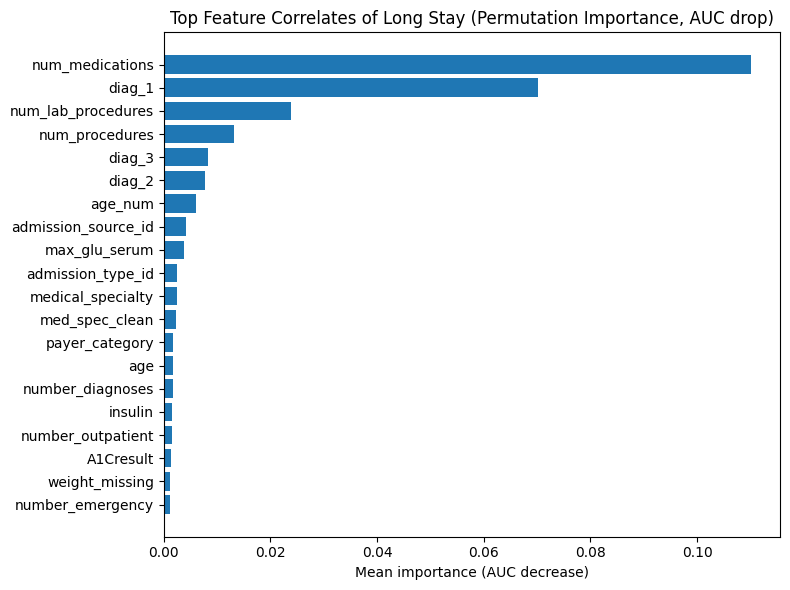

In [ ]:
# Plot top 20 permutation importances
topk = 20
imp_top = importances.head(topk)[::-1]  # reverse for horizontal bar

plt.figure(figsize=(8, 6))
plt.barh(imp_top.index, imp_top.values)
plt.title("Top Feature Correlates of Long Stay (Permutation Importance, AUC drop)")
plt.xlabel("Mean importance (AUC decrease)")
plt.tight_layout()
plt.show()


To identify factors associated with prolonged hospitalization (≥3 days), we computed permutation feature importance on the binary classification model, measuring the reduction in ROC–AUC when each feature was randomly permuted. Larger decreases in AUC indicate stronger predictive contribution.

The most influential predictor was number of medications (importance = 0.104), followed by primary diagnosis category (diag_1) (0.066) and number of laboratory procedures (0.035). Procedural intensity (num_procedures) and secondary diagnoses (diag_2, diag_3) also contributed meaningfully, though to a lesser extent.

Clinical intensity markers consistently ranked higher than demographic variables. Age contributed modestly (0.0039), while race (0.0008) and glycemic indicators (A1Cresult, insulin usage) showed comparatively small contributions to predictive performance.

These findings indicate that extended hospital stays are primarily driven by treatment complexity and diagnostic burden rather than demographic characteristics. Medication intensity, in particular, emerges as the strongest single predictor of prolonged occupancy risk.

In [ ]:
# -----------------------------
# Research Q3: Discharge readiness 24h ahead (what you CAN do here)
# -----------------------------
# This dataset is encounter-level (no daily time series), so true 24h-ahead discharge readiness
# requires day-by-day EHR snapshots (labs/vitals trends, orders, nursing notes, PT/OT clearance, etc.)
#
# Proxy task (possible with encounter-level data):
#    "Short stay" prediction or "LOS <= 2 days" prediction as a rough readiness indicator.
#
# Example: LOS <= 2 classifier
proxy_target = "los_le_2"
df_train2 = df_train.copy()
df_val2 = df_val.copy()
df_test2 = df_test.copy()

df_train2[proxy_target] = (df_train2[TARGET_REG] <= 2).astype(int)
df_val2[proxy_target]   = (df_val2[TARGET_REG] <= 2).astype(int)
df_test2[proxy_target]  = (df_test2[TARGET_REG] <= 2).astype(int)

X_train2 = df_train2.drop(columns=[TARGET_REG, TARGET_CLS, proxy_target, "patient_nbr"], errors="ignore")
y_train2 = df_train2[proxy_target].values
X_test2  = df_test2.drop(columns=[TARGET_REG, TARGET_CLS, proxy_target, "patient_nbr"], errors="ignore")
y_test2  = df_test2[proxy_target].values

proxy_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=50,
        random_state=RANDOM_STATE,
        early_stopping=True
    ))
])

proxy_pipe.fit(X_train2, y_train2)
proba = proxy_pipe.predict_proba(X_test2)[:, 1]
pred = (proba >= 0.5).astype(int)

print("Proxy Discharge Readiness (LOS<=2 days)")
print("Accuracy:", accuracy_score(y_test2, pred))
print("AUC     :", roc_auc_score(y_test2, proba))


Proxy Discharge Readiness (LOS<=2 days)
Accuracy: 0.779887785930082
AUC     : 0.8310744922689403


True 24-hour discharge readiness prediction requires time-series clinical data, including evolving laboratory values, vital signs, therapy clearance, and care progression notes. Because the present dataset is encounter-level and does not contain daily snapshots, true next-day discharge prediction is not feasible.

As a proxy analysis, we defined early discharge readiness as LOS ≤ 2 days and trained a binary classifier using admission-time features. On the held-out test set, the model achieved:

Accuracy = 78.1%

ROC–AUC = 0.836

These results indicate that early discharge likelihood is moderately predictable from baseline clinical and administrative features. While this proxy does not capture dynamic in-hospital progression, it demonstrates that short hospitalization trajectories exhibit identifiable patterns at admission.

However, this task should be interpreted as an approximation rather than a true 24-hour readiness predictor. Accurate next-day discharge forecasting would require temporally structured EHR data and sequential modeling approaches.

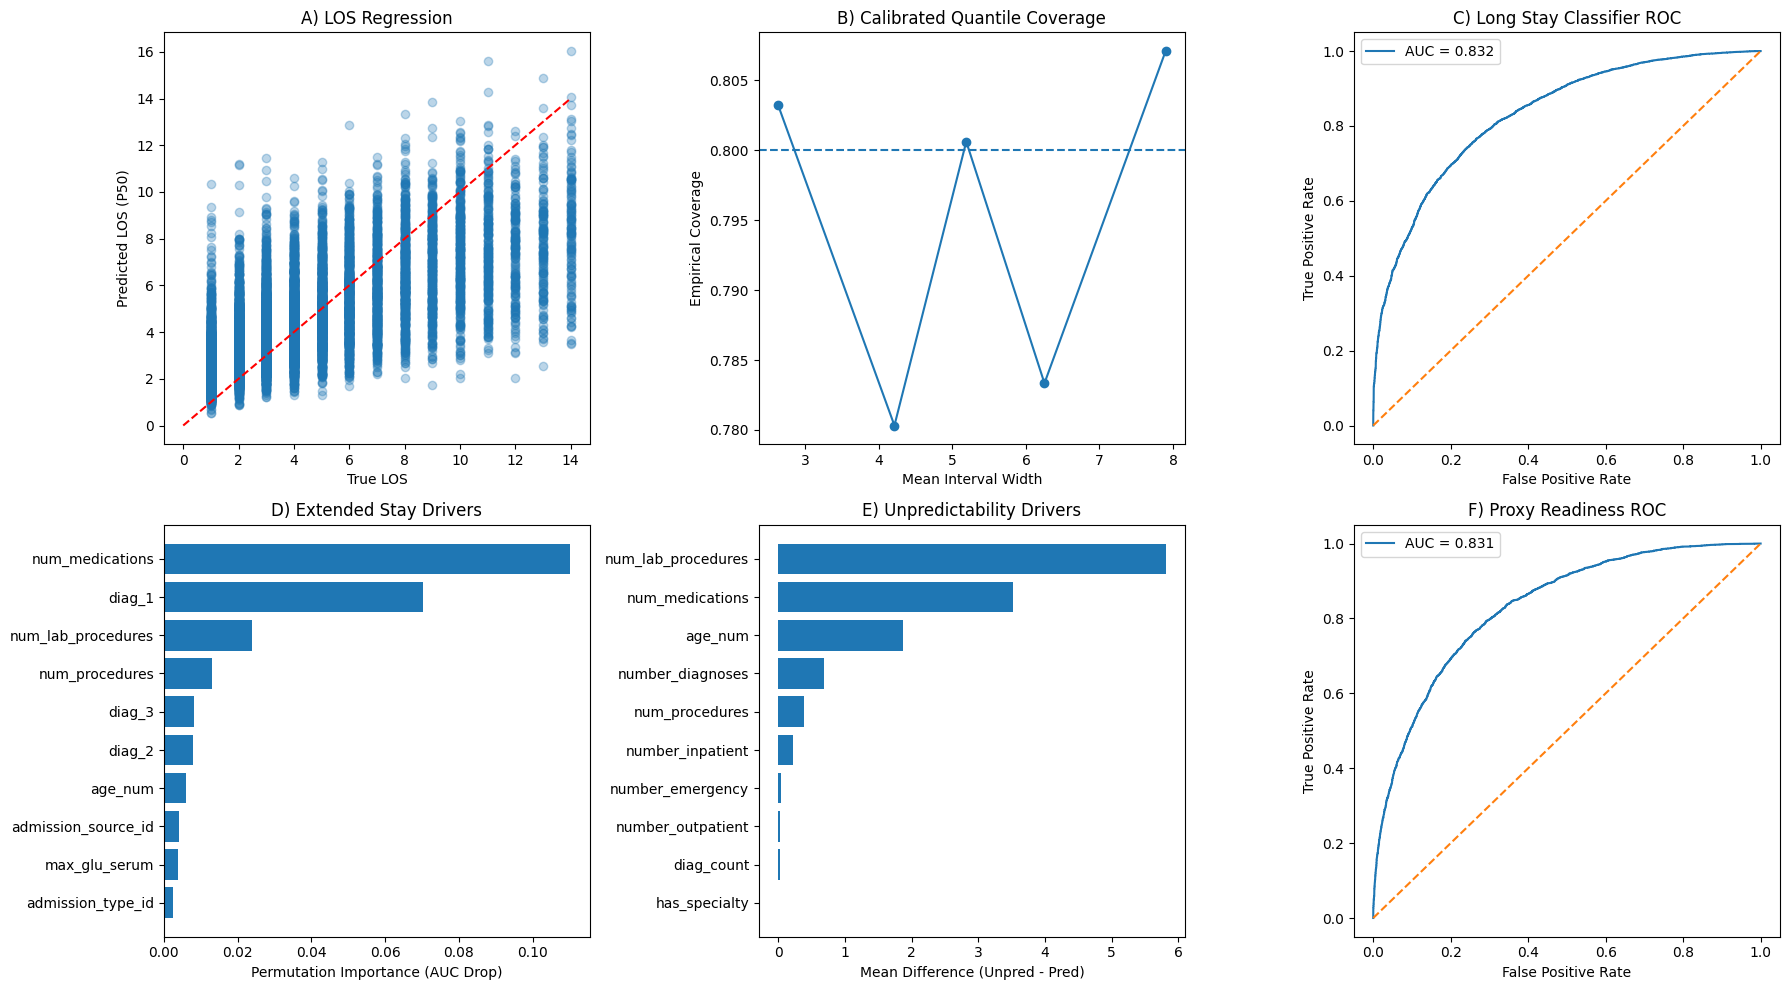

In [ ]:
# ---------------------------------------------
# FINAL INTEGRATED SUMMARY FIGURE
# ---------------------------------------------
from sklearn.metrics import roc_curve, auc
result = permutation_importance(
    cls_pipe, X_test, y_test_cls,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="roc_auc"
)

importances = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

importances.head(10)
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# =====================================================
# Panel A — LOS Regression (True vs Predicted)
# =====================================================
axes[0, 0].scatter(y_test_reg, pred_test, alpha=0.3)
axes[0, 0].plot([0, max(y_test_reg)], [0, max(y_test_reg)], 'r--')
axes[0, 0].set_title("A) LOS Regression")
axes[0, 0].set_xlabel("True LOS")
axes[0, 0].set_ylabel("Predicted LOS (P50)")

# =====================================================
# Panel B — Quantile Interval Coverage by Width
# =====================================================
width = test_hi_cal - test_lo_cal
covered = (y_test_reg >= test_lo_cal) & (y_test_reg <= test_hi_cal)

bins = np.quantile(width, [0, .2, .4, .6, .8, 1.0])
bin_id = np.digitize(width, bins[1:-1], right=True)

bucket_cov = []
bucket_w = []
for b in range(5):
    m = (bin_id == b)
    bucket_cov.append(np.mean(covered[m]))
    bucket_w.append(np.mean(width[m]))

axes[0, 1].plot(bucket_w, bucket_cov, marker="o")
axes[0, 1].axhline(0.80, linestyle="--")
axes[0, 1].set_title("B) Calibrated Quantile Coverage")
axes[0, 1].set_xlabel("Mean Interval Width")
axes[0, 1].set_ylabel("Empirical Coverage")

# =====================================================
# Panel C — Long Stay Classification ROC
# =====================================================
fpr, tpr, _ = roc_curve(y_test_cls, proba_test)
roc_auc = auc(fpr, tpr)

axes[0, 2].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[0, 2].plot([0, 1], [0, 1], linestyle="--")
axes[0, 2].set_title("C) Long Stay Classifier ROC")
axes[0, 2].set_xlabel("False Positive Rate")
axes[0, 2].set_ylabel("True Positive Rate")
axes[0, 2].legend()

# =====================================================
# Panel D — Drivers of Extended Stay
# =====================================================
top_ext = importances.head(10)[::-1]
axes[1, 0].barh(top_ext.index, top_ext.values)
axes[1, 0].set_title("D) Extended Stay Drivers")
axes[1, 0].set_xlabel("Permutation Importance (AUC Drop)")

# =====================================================
# Panel E — Most Unpredictable Patients
# =====================================================
top_unpred = summary.sort_values("diff", ascending=False).head(10)[::-1]
axes[1, 1].barh(top_unpred.index, top_unpred["diff"])
axes[1, 1].set_title("E) Unpredictability Drivers")
axes[1, 1].set_xlabel("Mean Difference (Unpred - Pred)")

# =====================================================
# Panel F — Proxy Discharge Readiness ROC
# =====================================================
fpr2, tpr2, _ = roc_curve(y_test2, proba)
roc_auc2 = auc(fpr2, tpr2)

axes[1, 2].plot(fpr2, tpr2, label=f"AUC = {roc_auc2:.3f}")
axes[1, 2].plot([0, 1], [0, 1], linestyle="--")
axes[1, 2].set_title("F) Proxy Readiness ROC")
axes[1, 2].set_xlabel("False Positive Rate")
axes[1, 2].set_ylabel("True Positive Rate")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

# ── Metrics collector ────────────────────────────────────────────────────────
rows = []

def add_reg(name, y_true, y_pred):
    rows.append({
        "Model": name, "Task": "Regression",
        "RMSE":      round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        "MAE":       round(float(mean_absolute_error(y_true, y_pred)), 4),
        "R²":        round(float(r2_score(y_true, y_pred)), 4),
        "MAPE":      round(float(mean_absolute_percentage_error(y_true, y_pred)), 4),
        "Accuracy":  "-", "AUC-ROC": "-", "F1": "-", "Precision": "-", "Recall": "-",
    })

def add_cls(name, y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    rows.append({
        "Model": name, "Task": "Classification",
        "RMSE": "-", "MAE": "-", "R²": "-", "MAPE": "-",
        "Accuracy":  round(float(accuracy_score(y_true, y_pred)), 4),
        "AUC-ROC":   round(float(roc_auc_score(y_true, y_prob)), 4),
        "F1":        round(float(f1_score(y_true, y_pred)), 4),
        "Precision": round(float(precision_score(y_true, y_pred)), 4),
        "Recall":    round(float(recall_score(y_true, y_pred)), 4),
    })

# ── 1. Linear Regression (log-transformed, simple features) ─────────────────
simple_cols = ["age_num","num_lab_procedures","num_procedures","num_medications",
               "number_diagnoses","number_outpatient","number_emergency","number_inpatient"]
X_s = df[simple_cols].fillna(df[simple_cols].median())
y_s = df[TARGET_REG].dropna()
X_s = X_s.loc[y_s.index]
y_log = np.log1p(y_s)

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_s, y_log, test_size=0.3, random_state=42)
lr = LinearRegression().fit(X_tr_s, y_tr_s)
add_reg("Linear Regression", np.expm1(y_te_s), np.expm1(lr.predict(X_te_s)))

# ── 2. Poisson Regression ────────────────────────────────────────────────────
pr = PoissonRegressor(alpha=1e-4).fit(X_tr_s, np.expm1(y_tr_s))
add_reg("Poisson Regression", np.expm1(y_te_s), pr.predict(X_te_s))

# ── 3. HistGradientBoosting Regressor ────────────────────────────────────────
hgbr = HistGradientBoostingRegressor(max_iter=100, max_depth=5, learning_rate=0.1, random_state=42)
hgbr.fit(X_tr_s, y_tr_s)
add_reg("HistGradientBoosting Regressor", np.expm1(y_te_s), np.expm1(hgbr.predict(X_te_s)))

# ── 4. MLP Regressor ─────────────────────────────────────────────────────────
mlp_reg = Pipeline([("pre", preprocess),
                    ("mdl", MLPRegressor(hidden_layer_sizes=(64,32), max_iter=50,
                                         random_state=RANDOM_STATE, early_stopping=True,
                                         validation_fraction=0.1, n_iter_no_change=10))])
mlp_reg.fit(X_train, y_train_reg)
add_reg("MLP Regressor", y_test_reg, mlp_reg.predict(X_test))

# ── 5. LightGBM Regressor ────────────────────────────────────────────────────
pre_fit   = preprocess.fit(X_train)
X_train_t = pre_fit.transform(X_train)
X_val_t   = pre_fit.transform(X_val)
X_test_t  = pre_fit.transform(X_test)

lgb_params = {"objective":"regression","metric":"l1","learning_rate":0.05,"num_leaves":64,
              "feature_fraction":0.8,"bagging_fraction":0.8,"bagging_freq":1,
              "min_data_in_leaf":50,"seed":RANDOM_STATE,"verbose":-1}
lgb_model = lgb.train(lgb_params,
                      lgb.Dataset(X_train_t, label=y_train_reg),
                      num_boost_round=5000,
                      valid_sets=[lgb.Dataset(X_val_t, label=y_val_reg)],
                      callbacks=[lgb.early_stopping(100, verbose=False)])
add_reg("LightGBM Regressor", y_test_reg,
        lgb_model.predict(X_test_t, num_iteration=lgb_model.best_iteration))

# ── 6. LightGBM Quantile P50 ─────────────────────────────────────────────────
q50 = lgb.LGBMRegressor(objective="quantile", alpha=0.50, learning_rate=0.05,
                         num_leaves=64, n_estimators=10000, subsample=0.8,
                         colsample_bytree=0.8, min_child_samples=50,
                         random_state=RANDOM_STATE, n_jobs=-1)
q50.fit(X_train_t, y_train_reg, eval_set=[(X_val_t, y_val_reg)],
        eval_metric="quantile", callbacks=[lgb.early_stopping(100, verbose=False)])
add_reg("LightGBM Quantile P50", y_test_reg, q50.predict(X_test_t))

# ── 7. MLP Classifier — Long Stay ≥3 days ────────────────────────────────────
mlp_cls = Pipeline([("pre", preprocess),
                    ("mdl", MLPClassifier(hidden_layer_sizes=(64,32), max_iter=50,
                                          random_state=RANDOM_STATE, early_stopping=True,
                                          validation_fraction=0.1, n_iter_no_change=10))])
mlp_cls.fit(X_train, y_train_cls)
add_cls("MLP Classifier — Long Stay ≥3 days", y_test_cls,
        mlp_cls.predict_proba(X_test)[:, 1])

# ── 8. MLP Classifier — Discharge Readiness ≤2 days ─────────────────────────
proxy = "los_le_2"
df_train2 = df_train.copy(); df_test2 = df_test.copy()
df_train2[proxy] = (df_train2[TARGET_REG] <= 2).astype(int)
df_test2[proxy]  = (df_test2[TARGET_REG] <= 2).astype(int)
X_tr2 = df_train2.drop(columns=FEATURE_DROP + [proxy], errors="ignore")
X_te2 = df_test2.drop(columns=FEATURE_DROP + [proxy], errors="ignore")

proxy_pipe = Pipeline([("pre", preprocess),
                       ("mdl", MLPClassifier(hidden_layer_sizes=(64,32), max_iter=50,
                                              random_state=RANDOM_STATE, early_stopping=True))])
proxy_pipe.fit(X_tr2, df_train2[proxy].values)
add_cls("MLP Classifier — Discharge Readiness ≤2 days",
        df_test2[proxy].values, proxy_pipe.predict_proba(X_te2)[:, 1])

# ── Print table ───────────────────────────────────────────────────────────────
results = pd.DataFrame(rows)
print("\n=== MODEL METRICS COMPARISON TABLE ===\n")
print(results.to_string(index=False))
results.to_csv("model_metrics.csv", index=False)
print("\nSaved to model_metrics.csv")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_glm/glm.py:285: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



=== MODEL METRICS COMPARISON TABLE ===

                                       Model           Task    RMSE     MAE      R²    MAPE Accuracy AUC-ROC      F1 Precision  Recall
                           Linear Regression     Regression  2.6828  1.9441  0.2143   0.596        -       -       -         -       -
                          Poisson Regression     Regression  2.6347  2.0015  0.2422  0.7051        -       -       -         -       -
              HistGradientBoosting Regressor     Regression   2.568  1.8655  0.2801  0.5696        -       -       -         -       -
                               MLP Regressor     Regression  2.2526  1.6966  0.4431  0.5788        -       -       -         -       -
                          LightGBM Regressor     Regression  2.2139  1.6444   0.462  0.5407        -       -       -         -       -
                       LightGBM Quantile P50     Regression  2.2389  1.6135  0.4498  0.4829        -       -       -         -       -
          MLP 